# 06 - Sample interval irregularity in LISST casts

Analysis of mooring data from PRTSZ-A (LISST 200-X) deployed on Pioneer MAB moorings identified an apparent drift in sample intervals that increased gradually during the burst sampling and more significantly over the course of an instrument deployment. This notebook applies a similar analysis to LISST data from the Pioneer-21 rosette mounted casts to check for irregularity in sample intervals during casts.

In [1]:
# Import libraries used in this notebook
import os
import re
import glob
import urllib.request as request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import xarray as xr
import cmocean
import cmocean.cm as cmo
import scipy.signal as signal
import seaborn as sns

## Define data import functions

Also define the path to data and load the headers for CSV parsing at this step.

In [2]:
# Load LISST CSV column names from json containing column headers
headers = pd.read_json("./inst_headers/lisst_hdr.json", typ='series', orient='records')
csvhdr = headers.iloc[0]

In [3]:
# Data loading function and constants
# Base url for data on Raw Data Archive
RDA_URL = "https://rawdata.oceanobservatories.org/files/cruise_data/Pioneer-MAB/Pioneer-21_AR87_2025-03-28/LISST/"

# General LISST data download and parsing into dataset
# Version 25 Aug 2025: Retain integer pandas index as
# sample number
def load_lisst(lisst_path, header):
    # Load LISST data from CSV
    lisst_df = pd.read_csv(lisst_path, names=header)
    try: lisst_df.head(1)
    except: print("No LISST data downloaded")

    # Rename integer index to sample number
    lisst_df.rename_axis("sample_number", inplace=True)
    
    # Create LISST time vector for Dataframe Index
    lisst_time = pd.to_datetime(lisst_df[
        ["year", "month", "day", "hour", "minute",
         "second"]
        ], yearfirst=True, utc=True)
    lisst_df.insert(0, "time", lisst_time.values)

    # Append LISST time index to integer sample
    # number index
    # lisst_df.set_index("time", drop=True,
                    #    append=True, inplace=True)
    
    # Convert data frame to Xarray Dataset for easy
    # manipulation
    lisst_ds = xr.Dataset.from_dataframe(lisst_df)
    
    # Create 2D array for binned volume concentration
    volumecon2D = list([])
    bins = list([])
    for var in lisst_ds.variables:
        if re.search("volumecon[0-9]+", var):
                bins.append(var)
                volumecon2D.append(lisst_ds[var])
    lisst_ds = lisst_ds.drop_vars(bins)
    str2num = lambda x: int(x.replace("volumecon", ""))
    bins = [str2num(x) for x in bins]
    lisst_ds["volume_concentration_2D"] = xr.concat(
        volumecon2D, pd.Index(bins, name="bin")
        )
    lisst_ds["volume_concentration_2D"] = lisst_ds["volume_concentration_2D"].assign_attrs(units="$\mu$L/L")

    # Mask data where depth < 0
    depth_mask = lisst_ds.sample_number[lisst_ds.depth>=0].values
    lisst_ds = lisst_ds.sel(sample_number=depth_mask)
    return lisst_ds

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kylene.cooley\AppData\Local\Temp\ipykernel_35844\3359376988.py:46: SyntaxWarning: invalid escape sequence '\m'
  lisst_ds["volume_concentration_2D"] = lisst_ds["volume_concentration_2D"].assign_attrs(units="$\mu$L/L")


In [4]:
# Scrape the LISST readme file on the RDA
# to get CSV file names for each cast
def scrape_lisst_list(readme_file):
    castfiles = {}
    filenext = False
    text, urlheaders =  request.urlretrieve(RDA_URL+readme_file)
    with open(text) as f:
        for x in f:
            if "CAST" in x:
                # print(x)
                cast = x.replace("    ", "")[:-1]
                filenext = True
                continue
            if (filenext is True)&(".CSV" in x):
                # print(x)
                file = x.replace("    ", "")[:-1]
                castfiles[cast] = file
                filenext = False
            else:
                continue
    # Sort dict values into list of tuples with
    # key, value pairs in castfiles:
    pairs = list(castfiles.items())
    return pairs

## Define data manipulation functions

In [5]:
# Define function to calculate the interval between samples in seconds
def time_to_next_sample(ds):
    time2 = ds.time[1:].values
    time1 = ds.time[:-1].values
    dtime = time2-time1
    dtime = dtime.astype("timedelta64[s]")
    return dtime

In [13]:
# Check sample intervals for anything over the expected sample interval
def find_irregular_dt(dtime, dt0):
    irregular = dtime!=dt0
    # idx = np.indices(dtime)
    # idx_irregular = zip(idx[0][irregular], idx[1][irregular])
    return np.any(irregular)

## Define plotting functions

In [14]:
# Define plotting and colormap functions
sns.set_style("darkgrid", {"axes.facecolor": "F7F2EE"})

def addprofile2axes(ax, data, variable, color, legendtitle=None, legendcol=1):
    ax.plot(data[variable], data["depth"],
             c=color, label=data.cast, alpha = 0.75)
    ax.legend(fontsize='xx-small', ncol=legendcol, title=legendtitle)
    ax.set_xlabel(variable.replace("_"," ").title())
    return ax

def rgb_from_dict(list_in, cmap):
    # Get dictionary for colormap with one color for each cast
    cmdict = cmocean.tools.get_dict(cmap, N=len(list_in)+2)
    # Make lists of RGB values for cast loop
    red = [float(x[1]) for x in cmdict["red"]]
    green = [float(x[1]) for x in cmdict["green"]]
    blue = [float(x[1]) for x in cmdict["blue"]]
    rgb = list(zip(red, green, blue))
    return rgb

def addintervals2axes(ax, data, color, datalabel=None):
    sample_interval = time_to_next_sample(data)
    irregular_intervals = find_irregular_dt(sample_interval, 2)
    if irregular_intervals:
        print(data.cast)
    # print(sample_interval.shape)
    # print(data["sample_number"][0:-3].shape)
    ax.scatter(data["sample_number"][:-1], sample_interval,
             c=color, label=datalabel, edgecolors="none")
    return ax

In [8]:
# define a function to plot casts in a group
def plot_lisst_profiles(lisst_casts, rgb, current_axes, param, legendtitle=None, legendcol=1):
    # loop through list of LISST cast files
    n = 0
    loop = lisst_casts.copy()
    while len(loop)>0:
        color = rgb[n+2]
        key, value = loop.pop(0)
        lisst_path = RDA_URL + value
        lisst_ds = load_lisst(lisst_path, csvhdr)
        lisst_ds = lisst_ds.assign_attrs(cast=key)
        # Add cast data to existing axes
        current_axes = addprofile2axes(current_axes, lisst_ds, param, color,
                                       legendtitle=legendtitle, legendcol=legendcol)
        # Advance counter for colors
        n += 1
    return current_axes

# define a function to plot sample intervals
# from many casts
def plot_lisst_interval(lisst_casts, color, current_axes, datalabel=None):
    # loop through list of LISST cast files
    loop = lisst_casts.copy()
    while len(loop)>0:
        # Load cast data
        key, value = loop.pop(0)
        lisst_path = RDA_URL + value
        lisst_ds = load_lisst(lisst_path, csvhdr)
        lisst_ds = lisst_ds.assign_attrs(cast=key)
        # Add cast data to existing axes
        if len(loop)==(len(lisst_casts)-1):
            current_axes = addintervals2axes(current_axes, lisst_ds, color,
                                             datalabel=datalabel)
        else:
            current_axes = addintervals2axes(current_axes, lisst_ds, color)
    return current_axes

## Import LISST data

In [9]:
# Load list of key, value pairs for each cast
readme_file = "AR87_LISST_README.txt"
pairs = scrape_lisst_list(readme_file)

In [10]:
cast0, file0 = pairs[0]
lisst_path = RDA_URL + file0
lisst_ds = load_lisst(lisst_path, csvhdr)
lisst_ds = lisst_ds.assign_attrs(cast=cast0)
lisst_ds

<xarray.Dataset> Size: 185kB
Dimensions:                  (sample_number: 366, bin: 36)
Coordinates:
  * sample_number            (sample_number) int64 3kB 101 102 103 ... 465 466
  * bin                      (bin) int64 288B 1 2 3 4 5 6 ... 31 32 33 34 35 36
Data variables: (12/27)
    time                     (sample_number) datetime64[ns] 3kB 2025-03-28T21...
    laser_transmission       (sample_number) float64 3kB 0.9978 ... 0.8972
    supply_voltage           (sample_number) float64 3kB 10.64 10.66 ... 10.58
    ext_in1                  (sample_number) int64 3kB 0 0 0 0 0 0 ... 0 0 0 0 0
    laser_ref                (sample_number) float64 3kB 1.055 1.055 ... 0.9495
    depth                    (sample_number) float64 3kB 0.16 1.35 ... 0.01 0.24
    ...                       ...
    rawpressure2             (sample_number) int64 3kB 22559 22746 ... 22572
    ambient_light            (sample_number) int64 3kB 4 3 3 3 4 3 ... 6 5 6 7 7
    ext_in3                  (sample_number) float64 3kB 1.722 1.264 ... 1.495
    optical_transmission     (sample_number) float64 3kB 0.97 0.951 ... 0.969
    beam_attenuation         (sample_number) float64 3kB 1.212 2.027 ... 1.266
    volume_concentration_2D  (bin, sample_number) float64 105kB 0.0 0.0 ... 0.0
Attributes:
    cast:     AR87a_CAST001_L6

## Plot sample interval

In [11]:
# Split casts into leg A and B lists
pairs87a = [x for x in pairs if "87a" in x[0]]
pairs87b = [x for x in pairs if "87b" in x[0]]

AR87a_CAST003_L10
AR87a_CAST004_GL564_GL376
AR87a_CAST006_SE
AR87a_CAST007_SE
AR87a_CAST012_AC1
AR87a_CAST014_NO
AR87b_CAST006_WE
AR87b_CAST007_WE
AR87b_CAST008_CS1
AR87b_CAST010_CS2
AR87b_CAST011_CS3
AR87b_CAST014_SO
AR87b_CAST015_SO
AR87b_CAST023_NO
AR87b_CAST032_L10
AR87b_CAST033_L8


(0.0, 12.0)

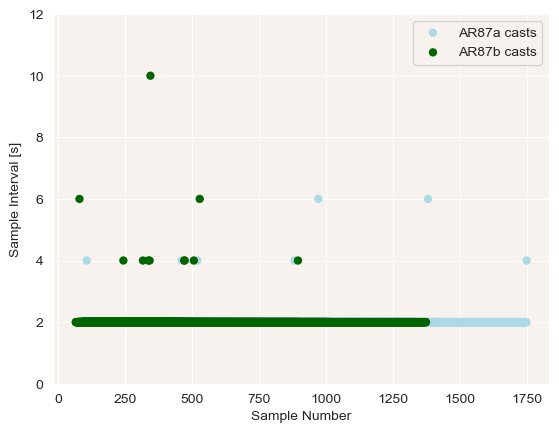

In [15]:
# Plot legs A and B on same axes with different colors
fig0, ax0 = plt.subplots()
ax0 = plot_lisst_interval(pairs87a, "lightblue", ax0, "AR87a casts")
ax0 = plot_lisst_interval(pairs87b, "darkgreen", ax0, "AR87b casts")


# Edit legend and axes labels
ax0.legend()
ax0.set_xlabel("Sample Number")
ax0.set_ylabel("Sample Interval [s]")
ax0.set_ylim([0, 12]) 
# One of the casts on AR87B has a long sample interval (400 s)
# when the cast was aborted but the sampling program
# was not restarted.

Text(0, 0.5, 'Sample Interval [s]')

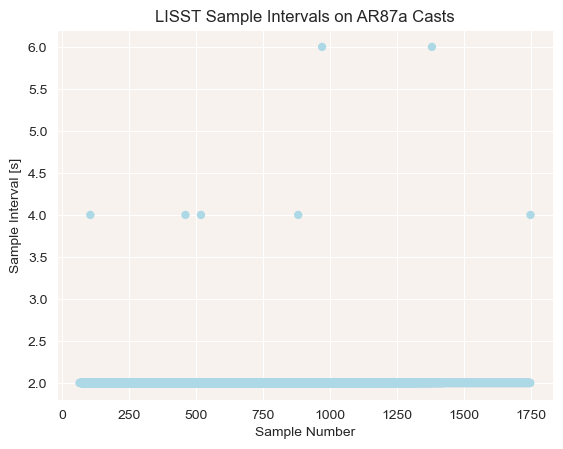

In [ ]:
# Plot Leg A by itself
fig1, ax1 = plt.subplots()
ax1 = plot_lisst_interval(pairs87a, "lightblue", ax1, "AR87a casts")

# Edit legend and axes labels
# ax1.legend()
plt.title("LISST Sample Intervals on AR87a Casts")
ax1.set_xlabel("Sample Number")
ax1.set_ylabel("Sample Interval [s]")

(0.0, 11.0)

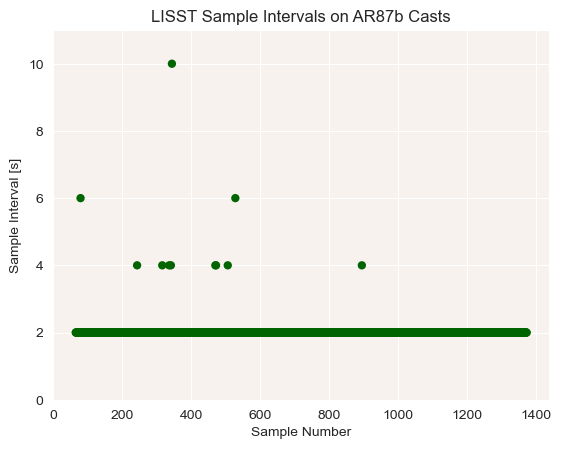

In [16]:
# Plot Leg B by itself
fig2, ax2 = plt.subplots()
ax2 = plot_lisst_interval(pairs87b, "darkgreen", ax2, "AR87b casts")

# Edit legend and axes labels
# ax2.legend()
plt.title("LISST Sample Intervals on AR87b Casts")
ax2.set_xlabel("Sample Number")
ax2.set_ylabel("Sample Interval [s]")
ax2.set_ylim([0, 11]) 
# One of the casts on AR87B has a long sample interval (400 s)
# when the cast was aborted but the sampling program
# was not restarted.

## Make individual plots of the longest casts

In [17]:
# Find the longest cast of each leg by sample number
def find_longest_cast(lisst_casts):
    # Loop through list of LISST files
    loop = lisst_casts.copy()
    while len(loop)>0:
        # Load cast data
        key, value = loop.pop(0)
        lisst_path = RDA_URL + value
        lisst_ds = load_lisst(lisst_path, csvhdr)
        lisst_ds = lisst_ds.assign_attrs(cast=key)
        if len(loop)==(len(lisst_casts)-1):
            cast_len = lisst_ds.sample_number[-1]
            return_ds = lisst_ds
        elif (lisst_ds.sample_number[-1])>cast_len:
            cast_len = lisst_ds.sample_number[-1]
            return_ds = lisst_ds
    return return_ds, cast_len

In [ ]:
# Find longest cast of Leg A and calculate sample intervals
long_ds_a, cast_len_a = find_longest_cast(pairs87a)
print(cast_len_a)

<xarray.DataArray 'sample_number' ()> Size: 8B
array(1374)
Coordinates:
    sample_number  int64 8B 1374


Text(0, 0.5, 'Sample Interval [s]')

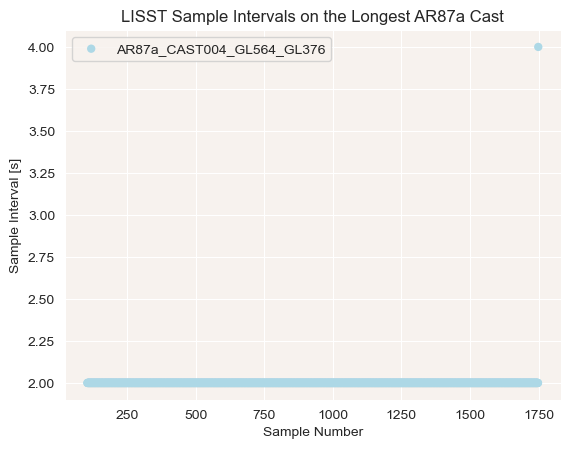

In [21]:
# Plot sample intervals of the longest cast of AR87a
fig3, ax3 = plt.subplots()
ax3 = addintervals2axes(ax3, long_ds_a, "lightblue", datalabel=long_ds_a.cast)
ax3.legend()
plt.title("LISST Sample Intervals on the Longest AR87a Cast")
ax3.set_xlabel("Sample Number")
ax3.set_ylabel("Sample Interval [s]")

In [23]:
# Find longest cast of Leg B and calculate sample intervals
long_ds_b, cast_len_b = find_longest_cast(pairs87b)
print(cast_len_b)

<xarray.DataArray 'sample_number' ()> Size: 8B
array(1374)
Coordinates:
    sample_number  int64 8B 1374


Text(0, 0.5, 'Sample Interval [s]')

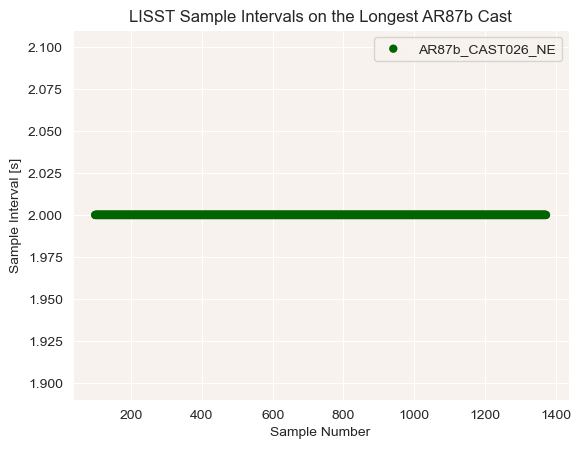

In [ ]:
# Plot sample intervals of the longest cast of AR87b
fig4, ax4 = plt.subplots()
ax4 = addintervals2axes(ax4, long_ds_b, "darkgreen", datalabel=long_ds_b.cast)
ax4.legend()
plt.title("LISST Sample Intervals on the Longest AR87b Cast")
ax4.set_xlabel("Sample Number")
ax4.set_ylabel("Sample Interval [s]")

## Make individual plots of last casts of each leg

In [34]:
# Get cast tuples for the last cast of each leg
last87a = list([pairs87a[-1]])
last87b = list([pairs87b[-1]])
# last87a.pop(0)

Text(0, 0.5, 'Sample Interval [s]')

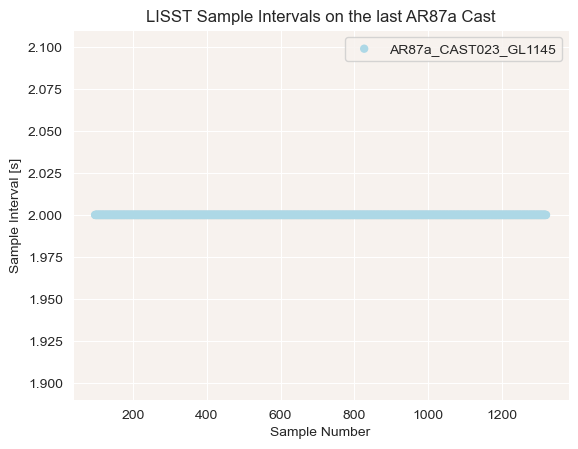

In [ ]:
# Plot last cast of Leg A
fig5, ax5 = plt.subplots()
ax5 = plot_lisst_interval(last87a, "lightblue", ax5, last87a[0][0])

# Edit legend and axes labels
ax5.legend()
plt.title("LISST Sample Intervals on the last AR87a Cast")
ax5.set_xlabel("Sample Number")
ax5.set_ylabel("Sample Interval [s]")

Text(0, 0.5, 'Sample Interval [s]')

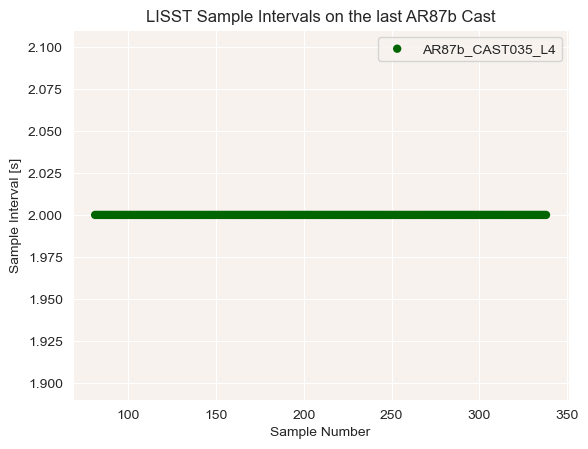

In [ ]:
# Plot last cast of Leg B
fig6, ax6 = plt.subplots()
ax6 = plot_lisst_interval(last87b, "darkgreen", ax6, last87b[0][0])

# Edit legend and axes labels
ax6.legend()
plt.title("LISST Sample Intervals on the last AR87b Cast")
ax6.set_xlabel("Sample Number")
ax6.set_ylabel("Sample Interval [s]")

## Individual plots for the casts with irregular sample intervals

AR87a_CAST003_L10


Text(0, 0.5, 'Sample Interval [s]')

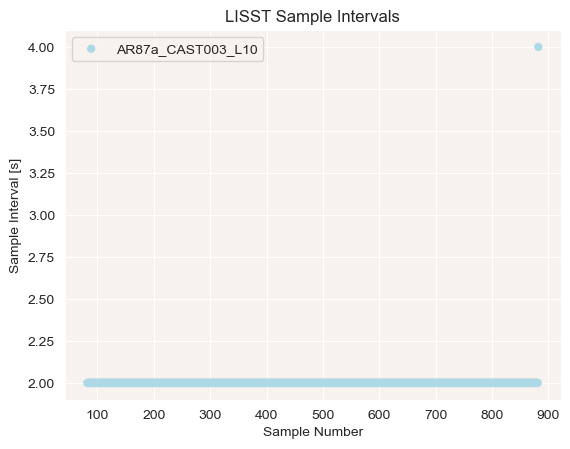

In [16]:
# AR87a_CAST003_L10
cast_file = [("AR87a_CAST003_L10", "I0880110.CSV")]
fig7, ax7 = plt.subplots()
ax7 = plot_lisst_interval(cast_file, "lightblue", ax7, "AR87a_CAST003_L10")

# Edit legend and axes labels
ax7.legend()
plt.title("LISST Sample Intervals")
ax7.set_xlabel("Sample Number")
ax7.set_ylabel("Sample Interval [s]")

AR87a_CAST004_GL564_GL376


Text(0, 0.5, 'Sample Interval [s]')

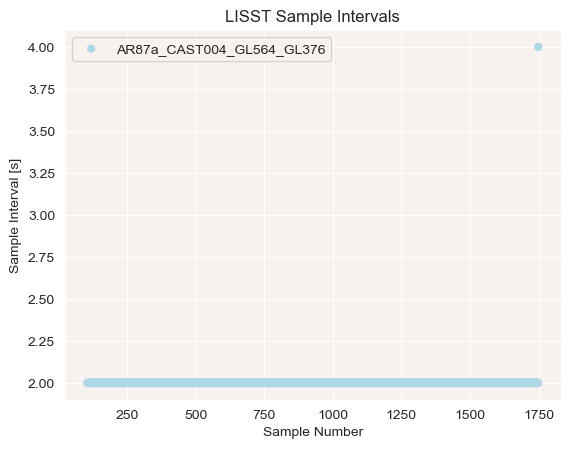

In [17]:
# AR87a_CAST004_GL564_GL376
cast_file = [("AR87a_CAST004_GL564_GL376", "I0891841.CSV")]
fig8, ax8 = plt.subplots()
ax8 = plot_lisst_interval(cast_file, "lightblue", ax8, "AR87a_CAST004_GL564_GL376")

# Edit legend and axes labels
ax8.legend()
plt.title("LISST Sample Intervals")
ax8.set_xlabel("Sample Number")
ax8.set_ylabel("Sample Interval [s]")

AR87a_CAST006_SE


Text(0, 0.5, 'Sample Interval [s]')

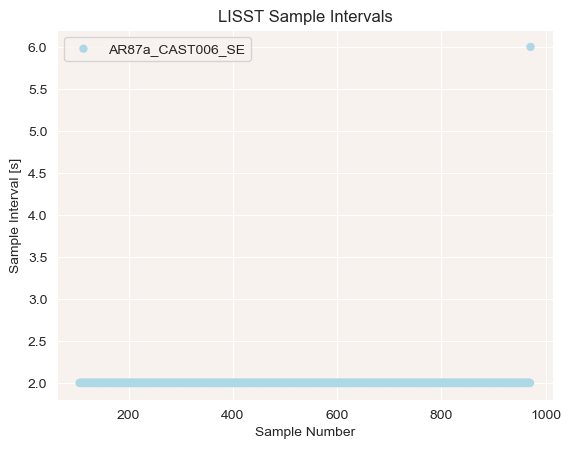

In [18]:
# AR87a_CAST006_SE
cast_file = [("AR87a_CAST006_SE", "I0901430.CSV")]
fig9, ax9 = plt.subplots()
ax9 = plot_lisst_interval(cast_file, "lightblue", ax9, "AR87a_CAST006_SE")

# Edit legend and axes labels
ax9.legend()
plt.title("LISST Sample Intervals")
ax9.set_xlabel("Sample Number")
ax9.set_ylabel("Sample Interval [s]")

AR87a_CAST007_SE


Text(0, 0.5, 'Sample Interval [s]')

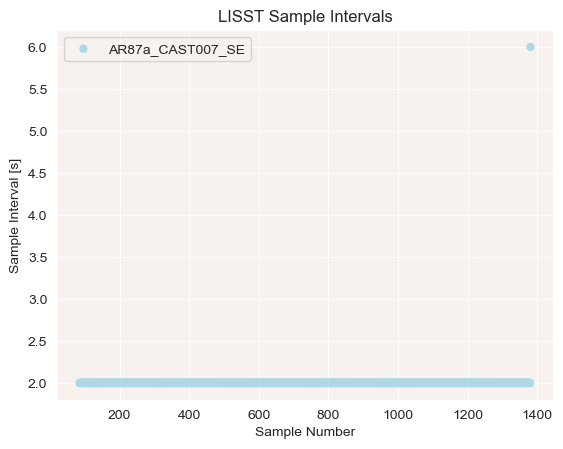

In [19]:
# AR87a_CAST007_SE
cast_file = [("AR87a_CAST007_SE", "I0901520.CSV")]
fig10, ax10 = plt.subplots()
ax10 = plot_lisst_interval(cast_file, "lightblue", ax10, "AR87a_CAST007_SE")

# Edit legend and axes labels
ax10.legend()
plt.title("LISST Sample Intervals")
ax10.set_xlabel("Sample Number")
ax10.set_ylabel("Sample Interval [s]")

AR87a_CAST012_AC1


Text(0, 0.5, 'Sample Interval [s]')

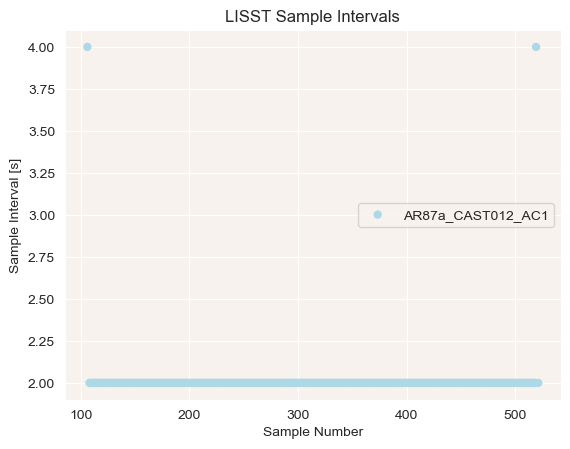

In [20]:
# AR87a_CAST012_AC1
cast_file = [("AR87a_CAST012_AC1", "I0931910.CSV")]
fig11, ax11 = plt.subplots()
ax11 = plot_lisst_interval(cast_file, "lightblue", ax11, "AR87a_CAST012_AC1")

# Edit legend and axes labels
ax11.legend()
plt.title("LISST Sample Intervals")
ax11.set_xlabel("Sample Number")
ax11.set_ylabel("Sample Interval [s]")

AR87a_CAST014_NO


Text(0, 0.5, 'Sample Interval [s]')

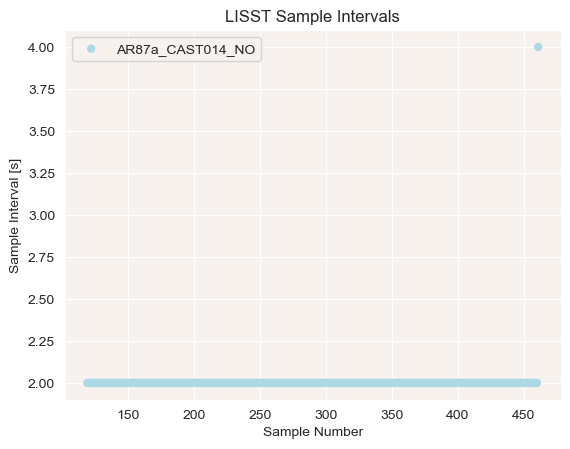

In [21]:
# AR87a_CAST014_NO
cast_file = [("AR87a_CAST014_NO", "I0940236.CSV")]
fig12, ax12 = plt.subplots()
ax12 = plot_lisst_interval(cast_file, "lightblue", ax12, "AR87a_CAST014_NO")

# Edit legend and axes labels
ax12.legend()
plt.title("LISST Sample Intervals")
ax12.set_xlabel("Sample Number")
ax12.set_ylabel("Sample Interval [s]")

AR87b_CAST006_WE


Text(0, 0.5, 'Sample Interval [s]')

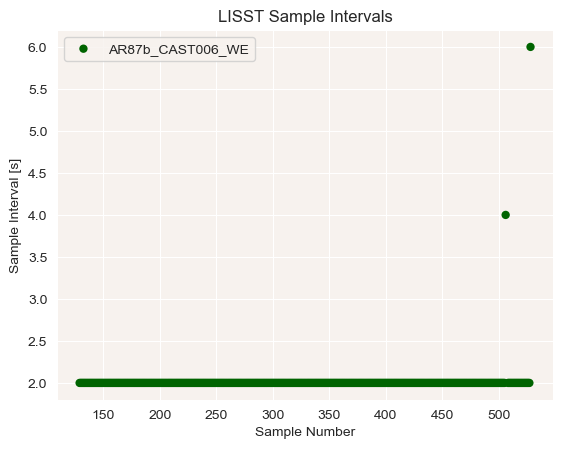

In [22]:
# AR87b_CAST006_WE
cast_file = [("AR87b_CAST006_WE", "I1022039.CSV")]
fig13, ax13 = plt.subplots()
ax13 = plot_lisst_interval(cast_file, "darkgreen", ax13, "AR87b_CAST006_WE")

# Edit legend and axes labels
ax13.legend()
plt.title("LISST Sample Intervals")
ax13.set_xlabel("Sample Number")
ax13.set_ylabel("Sample Interval [s]")

AR87b_CAST007_WE


Text(0, 0.5, 'Sample Interval [s]')

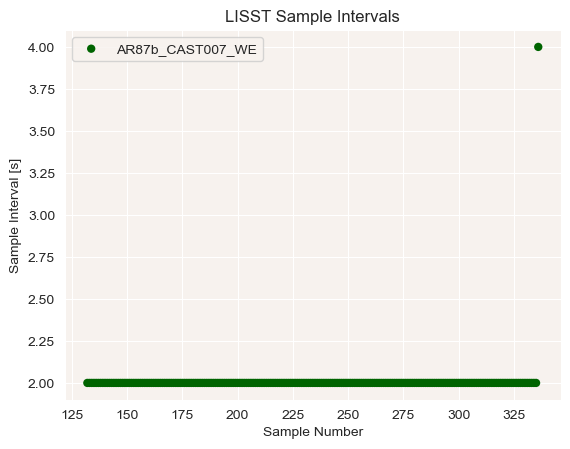

In [23]:
# AR87b_CAST007_WE
cast_file = [("AR87b_CAST007_WE", "I1031203.CSV")]
fig14, ax14 = plt.subplots()
ax14 = plot_lisst_interval(cast_file, "darkgreen", ax14, "AR87b_CAST007_WE")

# Edit legend and axes labels
ax14.legend()
plt.title("LISST Sample Intervals")
ax14.set_xlabel("Sample Number")
ax14.set_ylabel("Sample Interval [s]")

AR87b_CAST008_CS1


Text(0, 0.5, 'Sample Interval [s]')

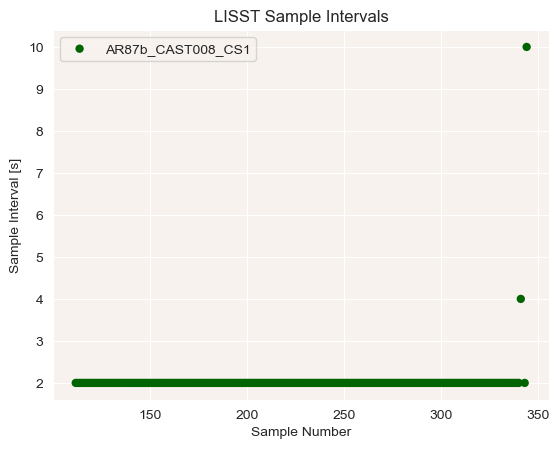

In [24]:
# AR87b_CAST008_CS1
cast_file = [("AR87b_CAST008_CS1", "I1031345.CSV")]
fig15, ax15 = plt.subplots()
ax15 = plot_lisst_interval(cast_file, "darkgreen", ax15, "AR87b_CAST008_CS1")

# Edit legend and axes labels
ax15.legend()
plt.title("LISST Sample Intervals")
ax15.set_xlabel("Sample Number")
ax15.set_ylabel("Sample Interval [s]")

AR87b_CAST010_CS2


Text(0, 0.5, 'Sample Interval [s]')

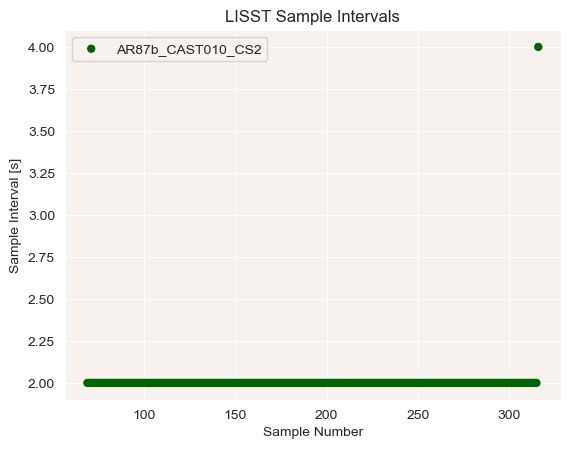

In [25]:
# AR87b_CAST010_CS2
cast_file = [("AR87b_CAST010_CS2", "I1031550.CSV")]
fig16, ax16 = plt.subplots()
ax16 = plot_lisst_interval(cast_file, "darkgreen", ax16, "AR87b_CAST010_CS2")

# Edit legend and axes labels
ax16.legend()
plt.title("LISST Sample Intervals")
ax16.set_xlabel("Sample Number")
ax16.set_ylabel("Sample Interval [s]")

AR87b_CAST011_CS3


Text(0, 0.5, 'Sample Interval [s]')

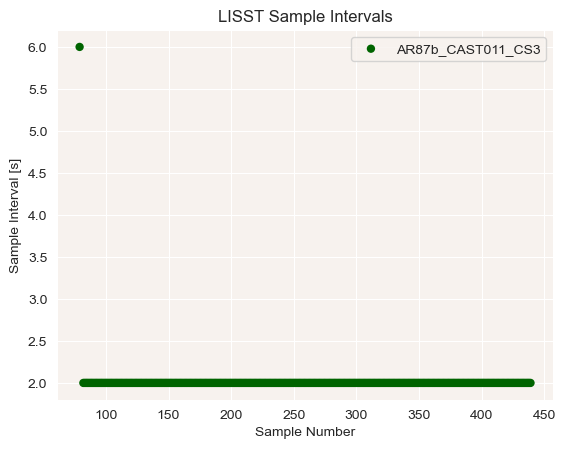

In [26]:
# AR87b_CAST011_CS3
cast_file = [("AR87b_CAST011_CS3", "I1031635.CSV")]
fig17, ax17 = plt.subplots()
ax17 = plot_lisst_interval(cast_file, "darkgreen", ax17, "AR87b_CAST011_CS3")

# Edit legend and axes labels
ax17.legend()
plt.title("LISST Sample Intervals")
ax17.set_xlabel("Sample Number")
ax17.set_ylabel("Sample Interval [s]")

AR87b_CAST014_SO


Text(0, 0.5, 'Sample Interval [s]')

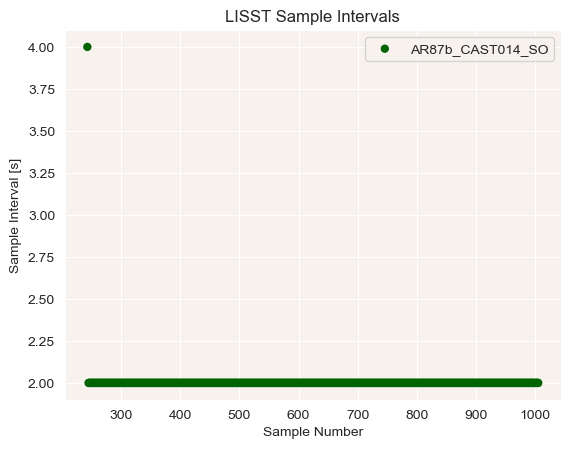

In [27]:
# AR87b_CAST014_SO
cast_file = [("AR87b_CAST014_SO", "I1041347.CSV")]
fig18, ax18 = plt.subplots()
ax18 = plot_lisst_interval(cast_file, "darkgreen", ax18, "AR87b_CAST014_SO")

# Edit legend and axes labels
ax18.legend()
plt.title("LISST Sample Intervals")
ax18.set_xlabel("Sample Number")
ax18.set_ylabel("Sample Interval [s]")

AR87b_CAST015_SO


Text(0, 0.5, 'Sample Interval [s]')

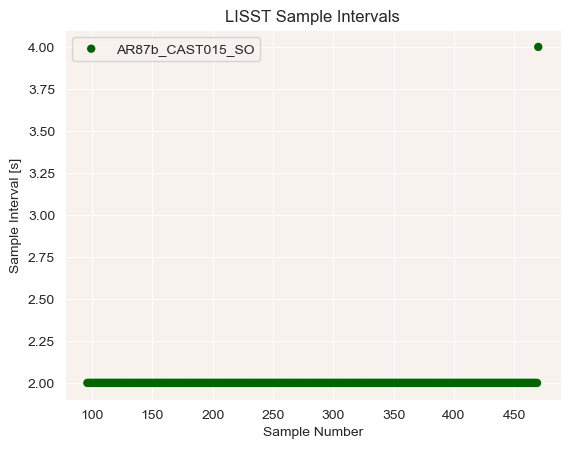

In [28]:
# AR87b_CAST015_SO
cast_file = [("AR87b_CAST015_SO", "I1041932.CSV")]
fig19, ax19 = plt.subplots()
ax19 = plot_lisst_interval(cast_file, "darkgreen", ax19, "AR87b_CAST015_SO")

# Edit legend and axes labels
ax19.legend()
plt.title("LISST Sample Intervals")
ax19.set_xlabel("Sample Number")
ax19.set_ylabel("Sample Interval [s]")

AR87b_CAST023_NO


Text(0, 0.5, 'Sample Interval [s]')

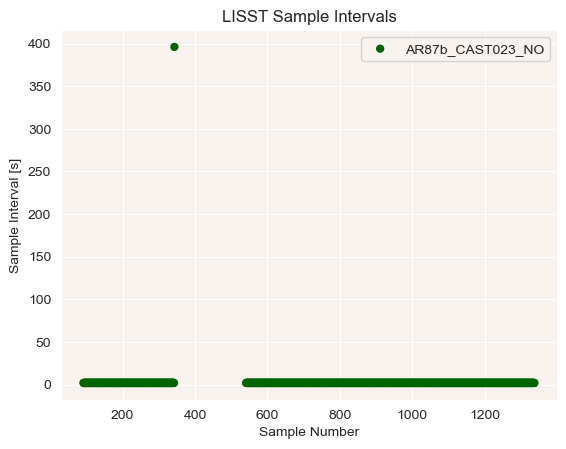

In [29]:
# AR87b_CAST023_NO
cast_file = [("AR87b_CAST023_NO", "I1051402.CSV")]
fig20, ax20 = plt.subplots()
ax20 = plot_lisst_interval(cast_file, "darkgreen", ax20, "AR87b_CAST023_NO")

# Edit legend and axes labels
ax20.legend()
plt.title("LISST Sample Intervals")
ax20.set_xlabel("Sample Number")
ax20.set_ylabel("Sample Interval [s]")

AR87b_CAST032_L10


Text(0, 0.5, 'Sample Interval [s]')

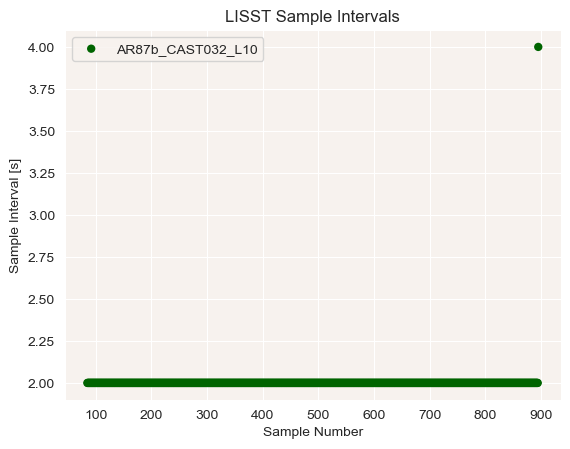

In [30]:
# AR87b_CAST032_L10
cast_file = [("AR87b_CAST032_L10", "I1092026.CSV")]
fig21, ax21 = plt.subplots()
ax21 = plot_lisst_interval(cast_file, "darkgreen", ax21, "AR87b_CAST032_L10")

# Edit legend and axes labels
ax21.legend()
plt.title("LISST Sample Intervals")
ax21.set_xlabel("Sample Number")
ax21.set_ylabel("Sample Interval [s]")

AR87b_CAST033_L8


Text(0, 0.5, 'Sample Interval [s]')

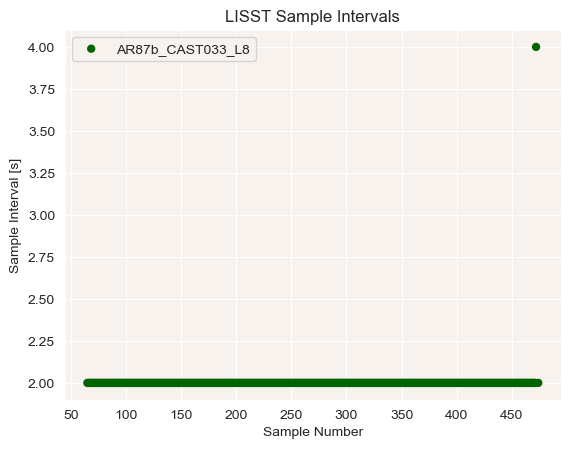

In [31]:
# AR87b_CAST033_L8
cast_file = [("AR87b_CAST033_L8", "I1092217.CSV")]
fig22, ax22 = plt.subplots()
ax22 = plot_lisst_interval(cast_file, "darkgreen", ax22, "AR87b_CAST033_L8")

# Edit legend and axes labels
ax22.legend()
plt.title("LISST Sample Intervals")
ax22.set_xlabel("Sample Number")
ax22.set_ylabel("Sample Interval [s]")